In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5005 - Linear Track Passive Navigation"
loc = join(figpath, code_id)
mkdir(loc)
pass

        D:\Yao Shuyang\En Lab\Results\5005 - Linear Track Passive Navigation is already existed!


[2.80259693e-45 5.60519386e-45]


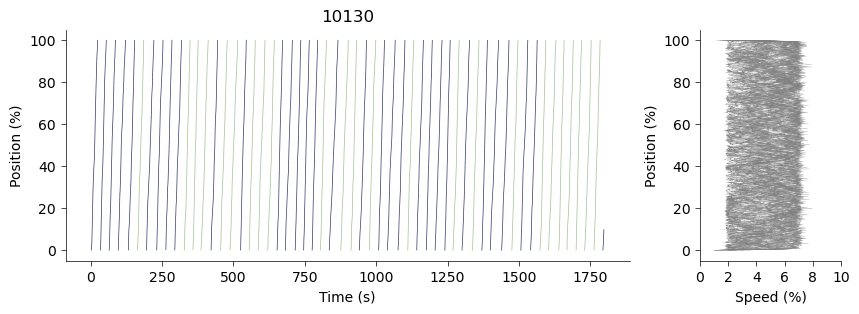

[2.80259693e-45 5.60519386e-45]


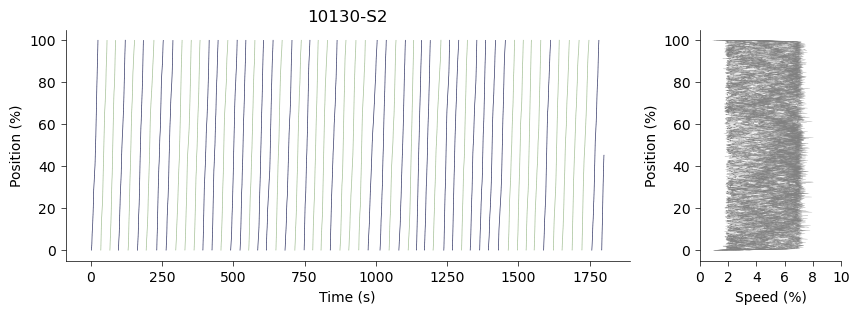

[2.80259693e-45 5.60519386e-45]


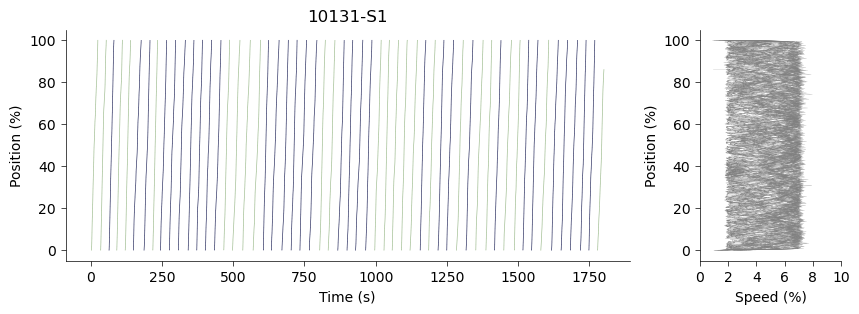

[2.80259693e-45 5.60519386e-45]


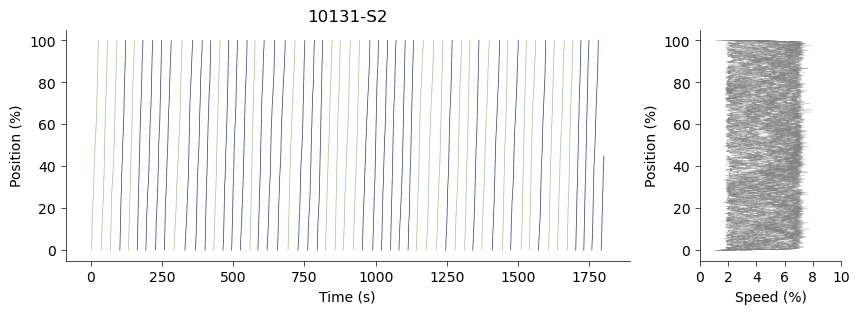

[2.80259693e-45 5.60519386e-45]


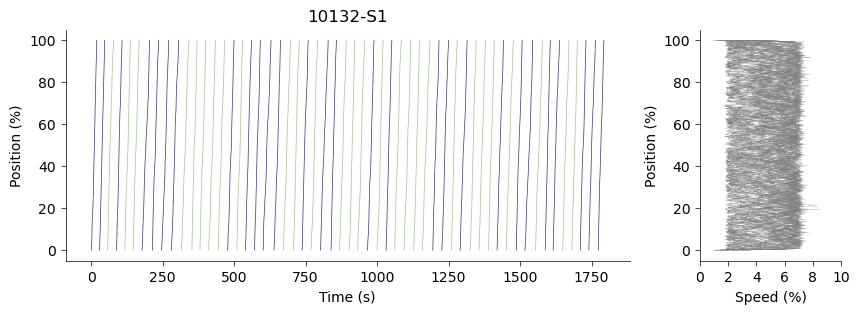

[2.80259693e-45 5.60519386e-45]


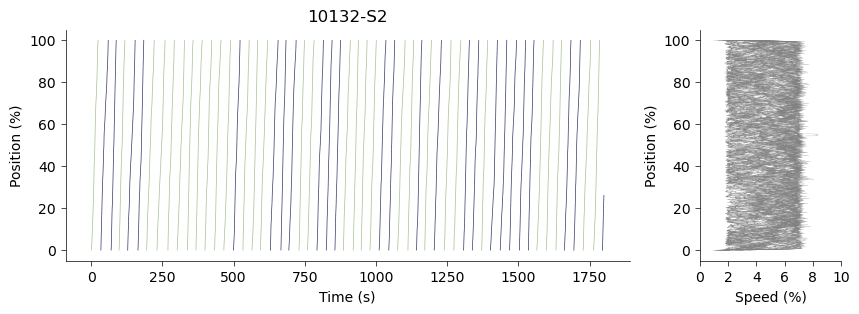

In [2]:
dirs = [
    r"D:\EnData\Light-sheet\10128\res.16chFlt",
    r"D:\EnData\Light-sheet\10129\res.16chFlt",
    r"D:\EnData\Light-sheet\10130\res.16chFlt",
    r"D:\EnData\Light-sheet\10130\S2\res.16chFlt",
    r"D:\EnData\Light-sheet\10131\S1\res.16chFlt",
    r"D:\EnData\Light-sheet\10131\S2\res.16chFlt",
    r"D:\EnData\Light-sheet\10132\res.16chFlt",
    r"D:\EnData\Light-sheet\10132\S2\res.16chFlt"
]
titles = [
    "10128",
    "10129",
    "10130",
    "10130-S2",
    "10131-S1",
    "10131-S2",
    "10132-S1",
    "10132-S2"
]
for dir, title, i in zip(dirs, titles, range(len(dirs))):
    if i <= 1:
        continue
        
        res = import16chFlt(dir, 16) 
        res['behav_pos_y'][(res['behav_pos_y'] < 6)] = np.nan
        idx = np.where(np.isnan(res['behav_pos_y']) == False)[0]
        res['behav_pos_y'][(res['behav_pos_y'] >105)] = np.nan
        fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 3), gridspec_kw={'width_ratios': [4, 1]})
        ax = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax.plot(res["behav_time"][idx], res["behav_pos_y"][idx])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Position (%)")
        ax.set_title(title)
        ax1 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        itip = np.where(np.diff(res["behav_pos_y"][idx]) > 10)[0]
        beg = np.concatenate(([0], itip + 1))
        end = np.concatenate((itip+1, [len(idx)]))
        for j in range(len(beg)):
            segment_idx = idx[beg[j]:end[j]][np.where(res['behav_speed_y'][idx[beg[j]:end[j]]] > 0)[0]]
            dt = np.diff(res['behav_time'][segment_idx])
            dx = np.diff(res['behav_pos_y'][segment_idx])
            v = dx / dt
            v[(dx > 10) | (dx < 0)] = np.nan 
            v[np.isnan(v) == False] = np.convolve(v[np.isnan(v) == False], np.ones(1000)/1000, mode='same')
            ax1.plot(v, res['behav_pos_y'][segment_idx[:-1]], color='gray', linewidth=0.12)
        ax1.set_xlabel("Speed (%)")
        ax1.set_ylabel("Position (%)")
        ax1.set_ylim(ax.get_ylim())
        ax1.set_xlim(0, 10)
        ax1.set_xticks(np.linspace(0, 10, 6))
        plt.show()
        print(np.nanmax(res["behav_time"][idx]))
    else:
        res = import16chFlt(dir, 21)
        print(np.unique(res['map']))
        res['behav_pos_y'][(res['behav_pos_y'] >105)] = np.nan
        idxnan = np.where(np.isnan(res['behav_pos_y']) == True)[0]
        for k in res.keys():
            res[k] = np.delete(res[k], idxnan)

        idx = np.arange(len(res['behav_pos_y']))    
        fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 3), gridspec_kw={'width_ratios': [4, 1]})
        ax = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Position (%)")
        ax.set_title(title)
        ax1 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        itip = np.where(np.diff(res["behav_pos_y"]) < -5)[0]
        beg = np.concatenate(([0], itip + 1))
        end = np.concatenate((itip+1, [len(res['behav_pos_y'])]))
        for j in range(len(beg)):
            segment_idx = np.where(res['behav_speed_y'][beg[j]:end[j]] > 0)[0]
            dt = np.diff(res['behav_time'][beg[j]:end[j]][segment_idx])
            dx = np.diff(res['behav_pos_y'][beg[j]:end[j]][segment_idx])
            v = dx / dt
            v[(dx > 10) | (dx < 0)] = np.nan 
            v[np.isnan(v) == False] = np.convolve(v[np.isnan(v) == False], np.ones(1000)/1000, mode='same')
            colors = ['','#333766','#A4C096']
            nmap = int(res['map'][beg[j]:end[j]][segment_idx[-10]]*1e45/2)
            ax.plot(res['behav_time'][beg[j]:end[j]][segment_idx[:-1]], res['behav_pos_y'][beg[j]:end[j]][segment_idx[:-1]], color=colors[nmap], linewidth=0.5)
            ax1.plot(v, res['behav_pos_y'][beg[j]:end[j]][segment_idx[:-1]], color='gray', linewidth=0.12)
        ax1.set_xlabel("Speed (%)")
        ax1.set_ylabel("Position (%)")
        ax1.set_ylim(ax.get_ylim())
        ax1.set_xlim(0, 10)
        ax1.set_xticks(np.linspace(0, 10, 6))
        plt.show()